# Part 2 - Voice Recognition with Whisper

## Introduction

In this notebook, I explore automatic speech recognition using OpenAI's Whisper model.

The goal is to:
- test how well Whisper recognizes Finnish speech
- compare different model sizes (tiny, base, small, large)
- measure speed and accuracy differences
- analyze the effect of model size on transcription quality

In [33]:
import torch
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import time

## Audio Loading and Preprocessing

In this section, an audio file is loaded using librosa and resampled to 16 kHz.

We also:
- display the audio for playback
- calculate duration
- inspect basic audio properties

This ensures that the input is correctly formatted for the Whisper model.

In [ ]:
audio_file = "test-audio-1.wav"

y, sr = librosa.load(audio_file, sr=16000)

display(Audio(y, rate=sr))

duration = librosa.get_duration(y=y, sr=sr)

print(f"Duration: {duration:.2f} s")
print(f"Sample rate: {sr}")

Kesto: 6.76 s
Sample rate: 16000


## Waveform Visualization

The waveform shows how the audio signal changes over time.

It helps us visually inspect:
- speech segments
- silence
- noise levels

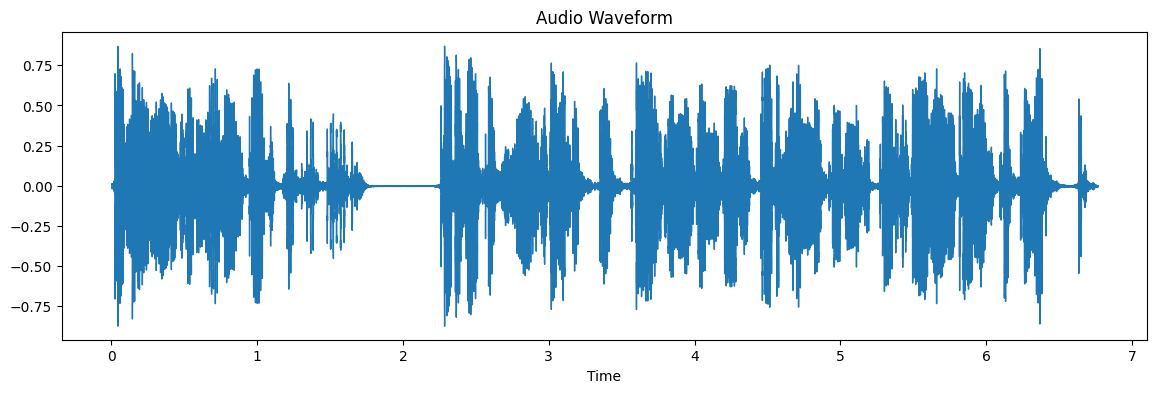

In [35]:
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Audio Waveform")
plt.show()

## Mel Spectrogram Representation

The audio signal is converted into a mel spectrogram.

- X-axis: time
- Y-axis: frequency (mel scale)
- Color intensity: signal strength (dB)

This representation is more suitable for neural networks than raw audio because it highlights speech patterns in a structured way.

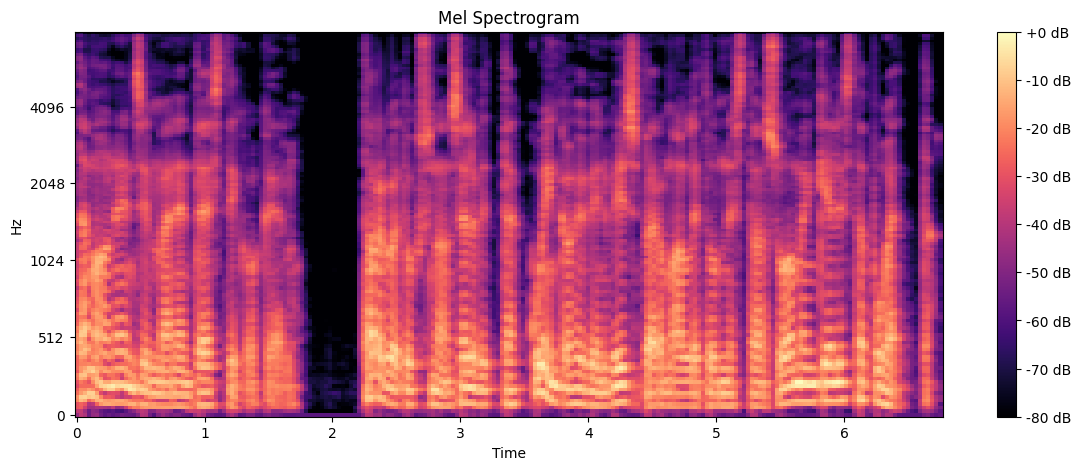

In [36]:
plt.figure(figsize=(14, 5))

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)

librosa.display.specshow(S_dB, y_axis='mel', x_axis='time', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.show()

## Device Selection

The model is run on the best available hardware:

- CUDA (GPU) if available
- Apple MPS if available
- otherwise CPU

This significantly affects processing speed.

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.mps.is_available() else device

print("Using device:", device)

Using device: cuda


## Whisper Model Inference (Single Run)

Here, a single Whisper model is used to transcribe Finnish speech.

We measure:
- transcription output quality
- inference time

This gives a baseline performance before comparing different model sizes.

In [38]:
model_size = "base"

model_name = f"openai/whisper-{model_size}"

processor = WhisperProcessor.from_pretrained(model_name)
model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)

input_features = processor(
    y,
    sampling_rate=sr,
    return_tensors="pt"
).input_features.to(device)

start = time.time()

with torch.no_grad():
    generated_ids = model.generate(input_features)

end = time.time()

transcription = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("Teksti:")
print(transcription)
print("Aika:", end - start)

Loading weights: 100%|██████████| 245/245 [00:00<00:00, 18876.26it/s]


Teksti:
 Tämä on ensimmäinen testikokeilu. Tarkoituksena on selvittää kuinka hyvin vispermallitunnistaan Suomen kielistä puhetta.
Aika: 0.18307280540466309


## Comparison of Different Whisper Models

We evaluate multiple Whisper model sizes:

- tiny
- base
- small
- large

For each model we measure:
- transcription accuracy (qualitative)
- processing time (quantitative)

This helps understand the trade-off between speed and performance.

In [39]:
model_sizes = ["tiny", "base", "small", "large"]

results = {}

for size in model_sizes:
    print(f"\n--- Model: {size} ---")
    
    model_name = f"openai/whisper-{size}"
    
    processor = WhisperProcessor.from_pretrained(model_name)
    model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)

    input_features = processor(
        y,
        sampling_rate=sr,
        return_tensors="pt"
    ).input_features.to(device)

    start = time.time()

    with torch.no_grad():
        generated_ids = model.generate(input_features)

    end = time.time()

    text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    print("Text:", text)
    print("Time:", end - start)

    results[size] = (text, end - start)


--- Model: tiny ---


Loading weights: 100%|██████████| 167/167 [00:00<00:00, 11682.52it/s]


Text:  Tämä on ensimmäinen testikokeelu. Tarkeutuksena on selvittää kuinka hyvin vispermanlle tunnistaan Suomen keilista puhetta.
Time: 0.12741494178771973

--- Model: base ---


Loading weights: 100%|██████████| 245/245 [00:00<00:00, 17047.47it/s]


Text:  Tämä on ensimmäinen testikokeilu. Tarkoituksena on selvittää kuinka hyvin vispermallitunnistaan Suomen kielistä puhetta.
Time: 0.17541098594665527

--- Model: small ---


Loading weights: 100%|██████████| 479/479 [00:00<00:00, 18173.09it/s]


Text:  Tämä on ensimmäinen testikokeelu. Tarkoituksena on selvittää, kuinka hyvin whisper-malli tunnistaa suomen kielistä puhetta.
Time: 0.3680136203765869

--- Model: large ---


Loading weights: 100%|██████████| 1259/1259 [00:00<00:00, 15047.10it/s]


Text:  Tämä on ensimmäinen testikokeilu. Tarkoituksena on selvittää kuinka hyvin Whisper-malli tunnistaa suomenkielistä puhetta.
Time: 1.2493071556091309


## Results Summary

Each model produces slightly different results in terms of:

- speed
- transcription accuracy
- handling of Finnish language

Generally:
- smaller models are faster but less accurate
- larger models are slower but more precise

## Final Transcriptions

Below are the outputs from all tested models.

These results are used to compare how model size affects recognition quality.

In [40]:
for size, (text, t) in results.items():
    print(f"\nModel: {size}")
    print(f"Time: {t:.2f}s")
    print(f"Output: {text}")


Model: tiny
Time: 0.13s
Output:  Tämä on ensimmäinen testikokeelu. Tarkeutuksena on selvittää kuinka hyvin vispermanlle tunnistaan Suomen keilista puhetta.

Model: base
Time: 0.18s
Output:  Tämä on ensimmäinen testikokeilu. Tarkoituksena on selvittää kuinka hyvin vispermallitunnistaan Suomen kielistä puhetta.

Model: small
Time: 0.37s
Output:  Tämä on ensimmäinen testikokeelu. Tarkoituksena on selvittää, kuinka hyvin whisper-malli tunnistaa suomen kielistä puhetta.

Model: large
Time: 1.25s
Output:  Tämä on ensimmäinen testikokeilu. Tarkoituksena on selvittää kuinka hyvin Whisper-malli tunnistaa suomenkielistä puhetta.
